# 04 – Bivariate Relationship Analysis

The goals are:
- Understand how user behavior interacts with product behavior
- Identify relationships that influence reorder probability
- Build intuition for feature interactions before modeling


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("instacart.db")


## User Order Count vs Reorder Probability
- Do frequent users reorder more often?
- Does reorder behavior increase with user engagement?

In [3]:
user_reorder = pd.read_sql("""
SELECT
    o.user_id,
    COUNT(o.order_id) AS total_orders,
    AVG(opp.reordered) AS reorder_ratio
FROM orders o
JOIN order_products_prior opp
    ON o.order_id = opp.order_id
GROUP BY o.user_id;
""", conn)

user_reorder.head()


,user_id,total_orders,reorder_ratio
0,1,59,0.694915
1,2,195,0.476923
2,3,88,0.625000
3,4,18,0.055556
4,5,37,0.378378


## User Activity vs Reorder Ratio

Each point represents a user.
We expect higher reorder ratios for frequent users.


Text(0, 0.5, 'Reorder Ratio')

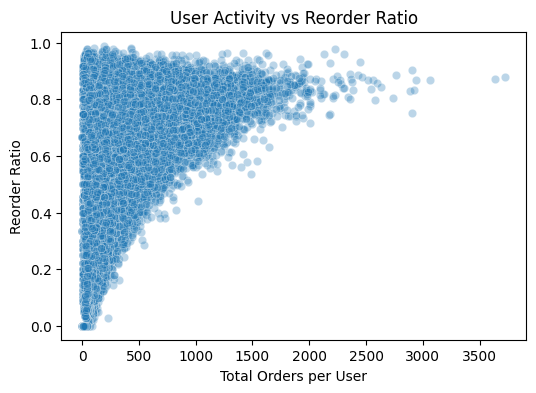

In [4]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=user_reorder,
    x="total_orders",
    y="reorder_ratio",
    alpha=0.3
)
plt.title("User Activity vs Reorder Ratio")
plt.xlabel("Total Orders per User")
plt.ylabel("Reorder Ratio")

### User Activity vs Reorder Ratio
- Users with very few orders show highly variable reorder ratios.
- As the number of orders increases, reorder ratios generally increase and become more stable.
- Highly active users tend to have consistently high reorder ratios. which means Frequent users develop stronger purchasing habits over time.

## Product Popularity vs Reorder Rate
- Are popular products reordered more?
- Or do niche products have stronger loyalty?


In [5]:
product_bivariate = pd.read_sql("""
SELECT
    product_id,
    COUNT(*) AS purchase_count,
    AVG(reordered) AS reorder_ratio
FROM order_products_prior
GROUP BY product_id;
""", conn)

product_bivariate.head()

,product_id,purchase_count,reorder_ratio
0,1,1852,0.613391
1,2,90,0.133333
2,3,277,0.732852
3,4,329,0.446809
4,5,15,0.600000


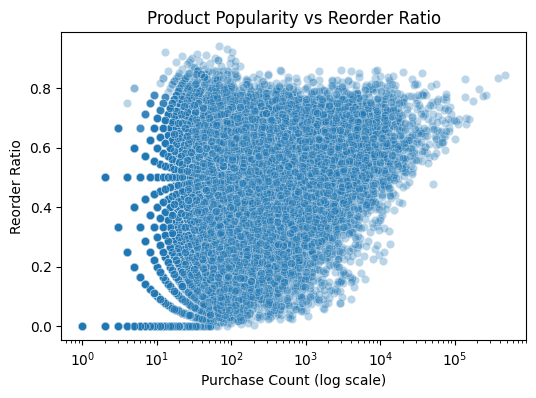

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=product_bivariate,
    x="purchase_count",
    y="reorder_ratio",
    alpha=0.3
)
plt.xscale("log")
plt.title("Product Popularity vs Reorder Ratio")
plt.xlabel("Purchase Count (log scale)")
plt.ylabel("Reorder Ratio")
plt.show()


### Product Popularity vs Reorder Ratio
- The distribution is highly scattered, indicating **weak correlation** between popularity and reorder behavior.
- Several products with **low purchase counts** exhibit **high reorder ratios**, suggesting niche but loyal products.
- Highly popular products show a wide range of reorder ratios, meaning popularity does not guarantee habitual consumption.

## Order Size vs Reorder Probability
 whether larger baskets contain more habitual items?


In [7]:
order_size_reorder = pd.read_sql("""
SELECT
    o.order_id,
    COUNT(opp.product_id) AS basket_size,
    AVG(opp.reordered) AS reorder_ratio
FROM orders o
JOIN order_products_prior opp
    ON o.order_id = opp.order_id
GROUP BY o.order_id;
""", conn)

order_size_reorder.head()


,order_id,basket_size,reorder_ratio
0,2,9,0.666667
1,3,8,1.000000
2,4,13,0.923077
3,5,26,0.807692
4,6,3,0.000000


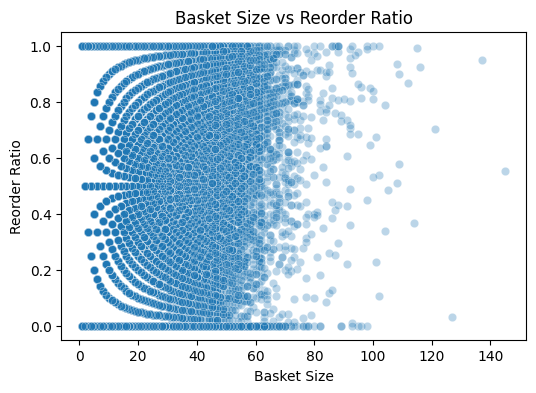

In [8]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=order_size_reorder,
    x="basket_size",
    y="reorder_ratio",
    alpha=0.3
)
plt.title("Basket Size vs Reorder Ratio")
plt.xlabel("Basket Size")
plt.ylabel("Reorder Ratio")
plt.show()

### Basket Size vs Reorder Ratio

- Smaller baskets show a wide spread of reorder ratios, including many low values.
- As basket size increases, reorder ratios tend to stabilize and shift upward.
- Large baskets are more likely to contain a higher proportion of reordered (habitual) items.


## Department-Level Reorder Behavior

This analysis answers:
- Which departments have stronger repeat purchase behavior?


In [9]:
dept_reorder = pd.read_sql("""
SELECT
    d.department,
    AVG(opp.reordered) AS reorder_ratio
FROM order_products_prior opp
JOIN products p
    ON opp.product_id = p.product_id
JOIN departments d
    ON p.department_id = d.department_id
GROUP BY d.department;
""", conn)

dept_reorder.head()

,department,reorder_ratio
0,alcohol,0.569924
1,babies,0.578971
2,bakery,0.628141
3,beverages,0.653460
4,breakfast,0.560922


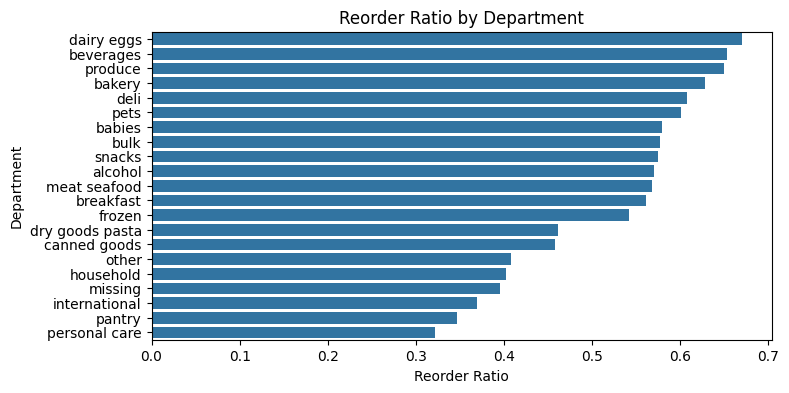

In [10]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=dept_reorder.sort_values("reorder_ratio", ascending=False),
    x="reorder_ratio",
    y="department"
)
plt.title("Reorder Ratio by Department")
plt.xlabel("Reorder Ratio")
plt.ylabel("Department")
plt.show()


### Reorder Ratio by Department
- **Dairy & Eggs, Beverages, and Produce** have the highest reorder ratios, indicating strong habitual purchasing.
- These departments mainly consist of **daily-use or staple items**, which users repurchase frequently.
- Categories such as **Personal Care, Pantry, and International** show significantly lower reorder ratios.
- Lower reorder ratios suggest more **exploratory or infrequent purchasing behavior** in these departments.


## User–Product Interaction Analysis
- How frequently a user purchases a specific product?
- How often those purchases are repeat purchases?




In [11]:
user_product = pd.read_sql("""
    SELECT
        o.user_id,
        opp.product_id,
        COUNT(*) AS times_bought,
        SUM(opp.reordered) AS times_reordered
    FROM order_products_prior opp
    JOIN orders o
        ON opp.order_id = o.order_id
    GROUP BY o.user_id, opp.product_id
""", conn)

user_product.head()


,user_id,product_id,times_bought,times_reordered
0,1,196,10,9
1,1,10258,9,8
2,1,10326,1,0
3,1,12427,10,9
4,1,13032,3,2


### Interpretation of User–Product 
- Most user–product pairs have very low interaction counts
- A small subset shows strong habitual behavior (high times_bought and times_reordered)
- This confirms that reorder behavior is **sparse and highly personalized**

## Analysis Summary

This notebook explored pairwise relationships between users, products, and contextual features to understand repeat purchase behavior.

Key findings include:

- **User activity and reorder behavior** show a strong relationship, with highly active users exhibiting more stable and higher reorder ratios.
- **Product popularity does not imply loyalty**; some niche products demonstrate high reorder ratios despite low purchase indicating strong habitual consumption.
- **Basket size influences reorder behavior**, where larger orders tend to contain a higher proportion of habitual items.
- **Department-level analysis** reveals clear behavioral segmentation, with staple categories (e.g., dairy, beverages, produce) exhibiting significantly higher reorder ratios.
- **User–product interaction analysis** confirms that reorder behavior is best understood at the interaction level rather than user-only or product-only views.

Overall, these results demonstrate that reorder behavior is:
- Non-linear
- Context-dependent
- Driven by interactions between users and products

These insights justify modeling reorder prediction at the **user–product level** and motivate the use of flexible, interaction-aware models in subsequent stages.
